In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.colors import ListedColormap


from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

np.random.seed(42)


In [3]:
#Loadng the dataset
df = pd.read_csv('adult.csv')

# Discover the data
df.info()

print(df.select_dtypes(include=['int']).columns.tolist())

<class 'pandas.DataFrame'>
RangeIndex: 32560 entries, 0 to 32559
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   39              32560 non-null  int64
 1    State-gov      32560 non-null  str  
 2    77516          32560 non-null  int64
 3    Bachelors      32560 non-null  str  
 4    13             32560 non-null  int64
 5    Never-married  32560 non-null  str  
 6    Adm-clerical   32560 non-null  str  
 7    Not-in-family  32560 non-null  str  
 8    White          32560 non-null  str  
 9    Male           32560 non-null  str  
 10   2174           32560 non-null  int64
 11   0              32560 non-null  int64
 12   40             32560 non-null  int64
 13   United-States  32560 non-null  str  
 14   <=50K          32560 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB
['39', ' 77516', ' 13', ' 2174', ' 0', ' 40']


Categorical features are : State-gov - Bachelors - Never-married - Adm-clerical - Not-in-family - White - Male - United-States - <=50K (needs encoding)
Numerical features are : 39 - 77516 - 13 - 2174 - 0 - 40 (needs standrization)

In [5]:
# Sort the features upon their types
cat_col = df.select_dtypes(include=['object']).columns.tolist()
num_col = df.select_dtypes(include=['int']).columns.tolist()

# scaling the numerical data

scaler_1 = StandardScaler()
scaler_2 = StandardScaler()

# fitting
df_scaled = scaler_1.fit_transform(df[num_col])

# Intiating new datafram as the previous method returns np array
df_scaled = pd.DataFrame(df_scaled,columns=num_col)

# Intiating onehot encoding
from sklearn.preprocessing import OneHotEncoder
enc = OneHotEncoder(sparse_output=False)

# fitting
df_ord = enc.fit_transform(df[cat_col])

# Intiating new datafram as this method returns np array
df_enc = pd.DataFrame(df_ord,columns=enc.get_feature_names_out(cat_col))

# Intiating the final df for preparing for the fitting
df_fin_one = pd.merge(df_scaled,df_enc,left_index=True,right_index=True)

# Preparing another DF for the fitting with arbitrary encoding
df_arb = df.copy()

# Another way for encoding (aribtary encoding)
for c in cat_col:

# Get unique categories
    unique_vals = df[c].unique()
    
# Generate random values (one for each unique category)
# np.random.rand(n) generates n values between 0 and 1
    random_values = np.random.rand(len(unique_vals))
    
# Create a mapping dictionary { 'CategoryName': 0.1234 }
    mapping = dict(zip(unique_vals, random_values))
    
# Apply the mapping to the column
    df_arb[c] = df[c].map(mapping)

# Scalling with new intiation to do not suffer from the previous scalling and on the raw data is better math wise
df_fin_arb_scl = scaler_2.fit_transform(df_arb)

display(df_fin_arb_scl,df_fin_one)

C:\Users\romma\AppData\Local\Temp\ipykernel_31436\634278863.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_col = df.select_dtypes(include=['object']).columns.tolist()


array([[ 0.83709708,  2.96526594, -1.0087417 , ..., -2.22212013,
        -0.24856564, -0.5632099 ],
       [-0.04264043, -0.31479961,  0.24504633, ..., -0.03542999,
        -0.24856564, -0.5632099 ],
       [ 1.05703146, -0.31479961,  0.42576955, ..., -0.03542999,
        -0.24856564, -0.5632099 ],
       ...,
       [ 1.42358875, -0.31479961, -0.3588108 , ..., -0.03542999,
        -0.24856564, -0.5632099 ],
       [-1.21562378, -0.31479961,  0.11092744, ..., -1.65520046,
        -0.24856564, -0.5632099 ],
       [ 0.98372   , -0.11319837,  0.92986178, ..., -0.03542999,
        -0.24856564,  1.77553698]])

,39,77516,13,2174,0,40,State-gov_ ?,State-gov_ Federal-gov,State-gov_ Local-gov,State-gov_ Never-worked,...,United-States_ Scotland,United-States_ South,United-States_ Taiwan,United-States_ Thailand,United-States_ Trinadad&Tobago,United-States_ United-States,United-States_ Vietnam,United-States_ Yugoslavia,<=50K_ <=50K,<=50K_ >50K
0,0.837097,-1.008742,1.134779,-0.145914,-0.216663,-2.222120,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,-0.042640,0.245046,-0.420027,-0.145914,-0.216663,-0.035430,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,1.057031,0.425770,-1.197429,-0.145914,-0.216663,-0.035430,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,-0.775755,1.408146,1.134779,-0.145914,-0.216663,-0.035430,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,-0.115952,0.898170,1.523480,-0.145914,-0.216663,-0.035430,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32555,-0.849066,0.639710,0.746077,-0.145914,-0.216663,-0.197407,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
32556,0.103982,-0.335466,-0.420027,-0.145914,-0.216663,-0.035430,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
32557,1.423589,-0.358811,-0.420027,-0.145914,-0.216663,-0.035430,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
32558,-1.215624,0.110927,-0.420027,-0.145914,-0.216663,-1.655200,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [5]:
# Initialize arrays for both metrics
si_one = np.zeros(10)
inertia_one = np.zeros(10)
k_one = np.arange(2, 12)

for i, k in enumerate(k_one):
    knn_one = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    knn_one.fit(df_fin_one)
    
    # Store Inertia (for Elbow Method)
    inertia_one[i] = knn_one.inertia_
    
    # Store Silhouette (for Peak Method)
    si_one[i] = silhouette_score(df_fin_one, knn_one.labels_)

# Finding the peak SI score after the loop finishes
opt_one_idx = np.argmax(si_one)
opt_one_k = k_one[opt_one_idx]
opt_one_si = si_one[opt_one_idx]

print(f'Analysis Complete.')
print(f'Optimum k by Silhouette: {opt_one_k} (Score: {opt_one_si:.4f})')
  

Analysis Complete.
Optimum k by Silhouette: 4 (Score: 0.1295)


In [6]:
# Initialize arrays for k=2 to k=11
si_arb = np.zeros(10)
inertia_arb = np.zeros(10)
k_range = np.arange(2, 12)

for i, k in enumerate(k_range):
    # Initializing KMeans for Arbitrary Encoded data
    knn_arb = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    knn_arb.fit(df_fin_arb_scl)
    
    # 1. Store Inertia for Elbow Method
    inertia_arb[i] = knn_arb.inertia_
    
    # 2. Store Silhouette Score for Peak Method
    si_arb[i] = silhouette_score(df_fin_arb_scl, knn_arb.labels_)

# Finding the peak results after the loop is complete
opt_arb_idx = np.argmax(si_arb)
opt_arb_k = k_range[opt_arb_idx]
opt_arb_si = si_arb[opt_arb_idx]

print(f"Arbitrary Encoding Analysis Complete.")
print(f"Best Silhouette Score: {opt_arb_si:.4f} at k = {opt_arb_k}")

Arbitrary Encoding Analysis Complete.
Best Silhouette Score: 0.1463 at k = 8


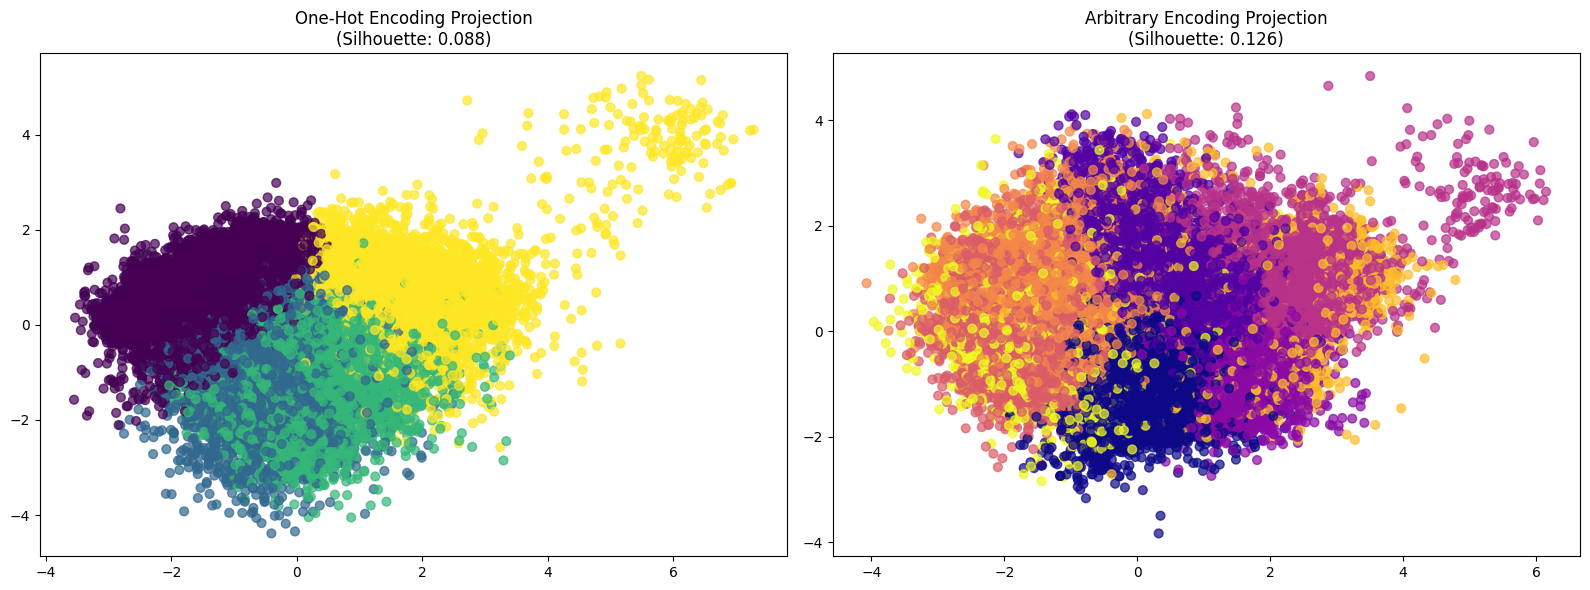

In [8]:
from sklearn.decomposition import PCA

# Run final KMeans for the "best" k found in your loops
km_one = KMeans(n_clusters=opt_one_k, random_state=42).fit(df_fin_one)
km_arb = KMeans(n_clusters=opt_arb_k, random_state=42).fit(df_fin_arb_scl)

# PCA Projection
pca = PCA(n_components=2)
pca_one = pca.fit_transform(df_fin_one)
pca_arb = pca.fit_transform(df_fin_arb_scl)

# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# One-Hot
ax1.scatter(pca_one[:, 0], pca_one[:, 1], c=km_one.labels_, cmap='viridis', s=40, alpha=0.7)
ax1.set_title(f'One-Hot Encoding Projection\n(Silhouette: {silhouette_score(df_fin_one, km_one.labels_):.3f})')

# Arbitrary
ax2.scatter(pca_arb[:, 0], pca_arb[:, 1], c=km_arb.labels_, cmap='plasma', s=40, alpha=0.7)
ax2.set_title(f'Arbitrary Encoding Projection\n(Silhouette: {silhouette_score(df_fin_arb_scl, km_arb.labels_):.3f})')

plt.tight_layout()
plt.show()

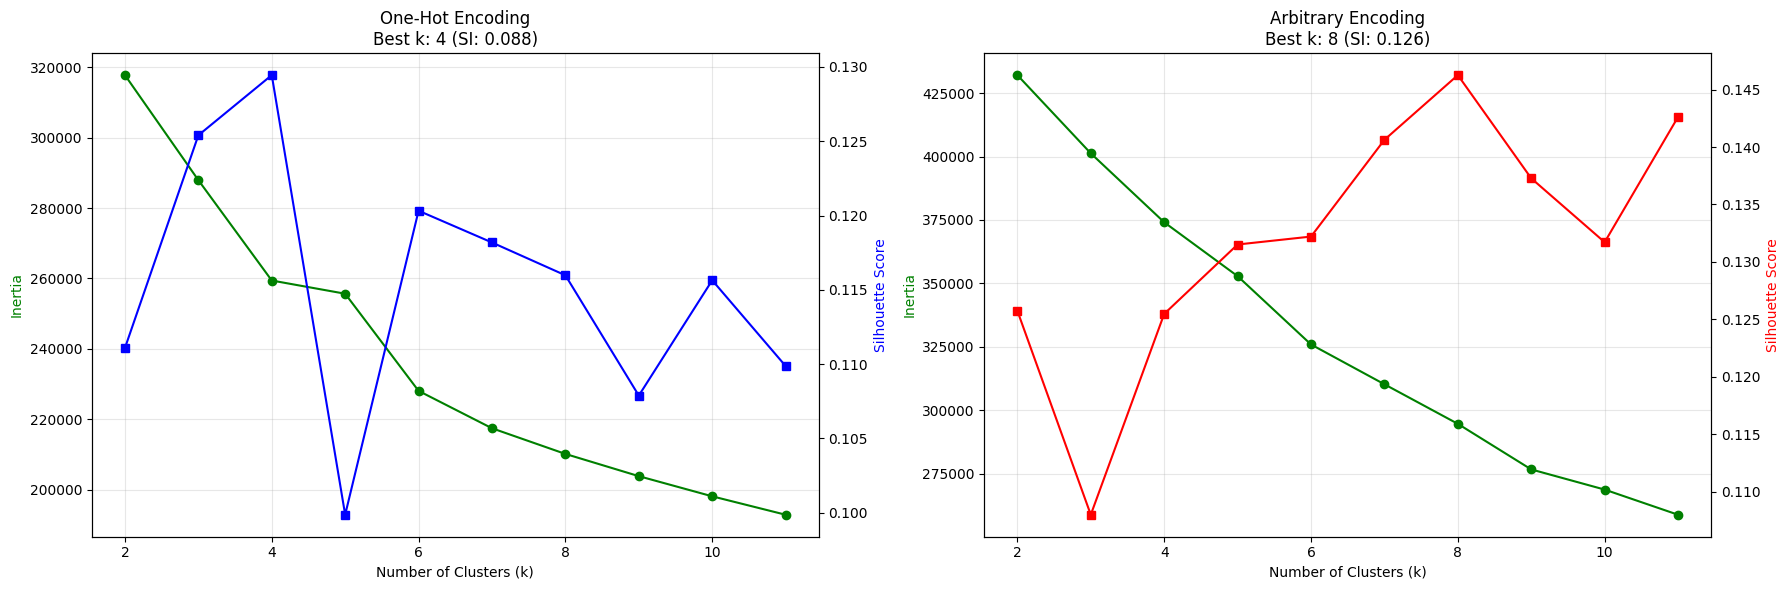

In [9]:
import matplotlib.pyplot as plt

fig, (ax_one, ax_arb) = plt.subplots(1, 2, figsize=(18, 6))

# --- Plot 1: One-Hot Encoding Performance ---
ax_one_si = ax_one.twinx()
ax_one.plot(k_range, inertia_one, 'g-', marker='o', label='Inertia (Elbow)')
ax_one_si.plot(k_range, si_one, 'b-', marker='s', label='Silhouette (Peak)')
ax_one.set_title(f'One-Hot Encoding\nBest k: {km_one.n_clusters} (SI: {silhouette_score(df_fin_one, km_one.labels_):.3f})')
ax_one.set_xlabel('Number of Clusters (k)')
ax_one.set_ylabel('Inertia', color='g')
ax_one_si.set_ylabel('Silhouette Score', color='b')
ax_one.grid(True, alpha=0.3)

# --- Plot 2: Arbitrary Encoding Performance ---
ax_arb_si = ax_arb.twinx()
ax_arb.plot(k_range, inertia_arb, 'g-', marker='o', label='Inertia (Elbow)')
ax_arb_si.plot(k_range, si_arb, 'r-', marker='s', label='Silhouette (Peak)')
ax_arb.set_title(f'Arbitrary Encoding\nBest k: {km_arb.n_clusters} (SI: {silhouette_score(df_fin_arb_scl, km_arb.labels_):.3f})')
ax_arb.set_xlabel('Number of Clusters (k)')
ax_arb.set_ylabel('Inertia', color='g')
ax_arb_si.set_ylabel('Silhouette Score', color='r')
ax_arb.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
# Assign the labels to a new column
df['Cluster_Label'] = km_arb.labels_

# Sort the DataFrame by that new column
df.sort_values(by='Cluster_Label', inplace=True)

# View the results
display(df.head())

,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,Cluster_Label
45,53,Private,144361,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,38,United-States,<=50K,0
47,41,State-gov,101603,Assoc-voc,11,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,<=50K,0
32546,43,Private,260761,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,Mexico,<=50K,0
37,31,Private,84154,Some-college,10,Married-civ-spouse,Sales,Husband,White,Male,0,0,38,?,>50K,0
38,48,Self-emp-not-inc,265477,Assoc-acdm,12,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,40,United-States,<=50K,0


In [6]:
lin_type = ['ward','single','complete','average']
hi_labels = pd.DataFrame(columns=lin_type)
hi_dict = {}
for l in lin_type :
    print(f'Know we are in {l} method')
    agg = AgglomerativeClustering(n_clusters=8,metric='euclidean',linkage=l,compute_distances=False).fit(df_fin_arb_scl)
    hi_dict[l]= silhouette_score(df_fin_arb_scl,agg.labels_)
    hi_labels[l] = agg.labels_

print(hi_dict)

Know we are in ward method
Know we are in single method
Know we are in complete method
Know we are in average method
{'ward': 0.17261880167030508, 'single': 0.35137640871959414, 'complete': 0.059145721363147837, 'average': 0.3002059177715303}


Plotting Dendrogram for the best linkage: single


C:\Users\romma\AppData\Local\Temp\ipykernel_31436\4086072288.py:34: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig('dendrogram_plot.png')
C:\Users\romma\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


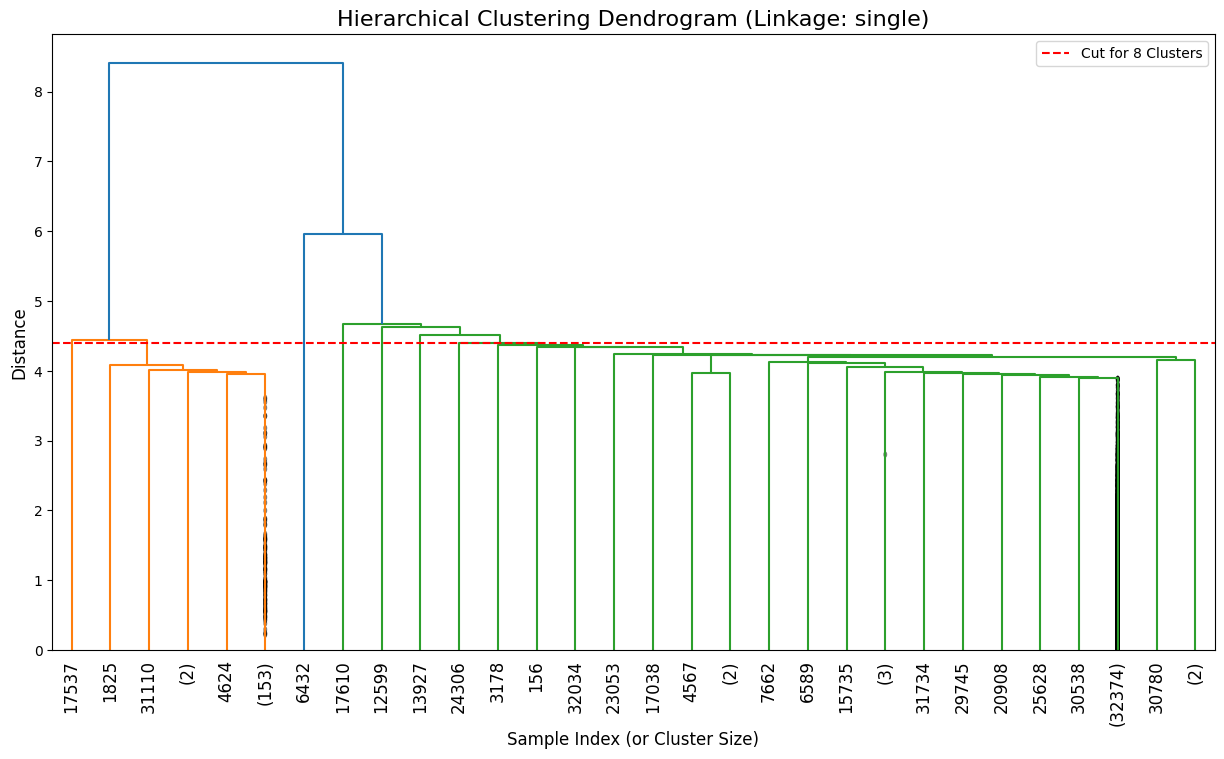

In [7]:

# 1. Identify the linkage with the highest Silhouette Score
best_l = max(hi_dict, key=hi_dict.get)
print(f"Plotting Dendrogram for the best linkage: {best_l}")

# 2. Generate the Linkage Matrix using SciPy
# Note: SciPy uses 'method' instead of 'linkage'
Z = linkage(df_fin_arb_scl, method=best_l, metric='euclidean')

# 3. Create the Visualization
plt.figure(figsize=(15, 8))
plt.title(f'Hierarchical Clustering Dendrogram (Linkage: {best_l})', fontsize=16)
plt.xlabel('Sample Index (or Cluster Size)', fontsize=12)
plt.ylabel('Distance', fontsize=12)

# Plotting the dendrogram
# truncate_mode='lastp' and p=30 helps if you have thousands of rows
dendrogram(
    Z,
    truncate_mode='lastp',  # show only the last p merged clusters
    p=30,                   # show 30 leaf nodes
    show_leaf_counts=True,  # numbers in brackets are the count of samples in that node
    leaf_rotation=90.,
    leaf_font_size=12.,
    show_contracted=True,   # to get a distribution impression in truncated branches
)

# Add a horizontal line representing your chosen n_clusters (e.g., 8)
# This helps visualize where the tree "cuts" to create your groups
# We find the distance of the 8th to last merge
cut_distance = Z[-(8-1), 2] 
plt.axhline(y=cut_distance, color='r', linestyle='--', label=f'Cut for 8 Clusters')
plt.legend()

plt.savefig('dendrogram_plot.png')